In [394]:
import matplotlib.pyplot as plt
import librosa
import numpy as np
from IPython.display import Audio, display

import ruptures as rpt  # our packageimport matplotlib.pyplot as plt
from scipy.stats import zscore
from ruptures.base import BaseCost
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks


In [395]:
def fig_ax(figsize=(15, 5), dpi=150):
    """Return a (matplotlib) figure and ax objects with given size."""
    return plt.subplots(figsize=figsize, dpi=dpi)


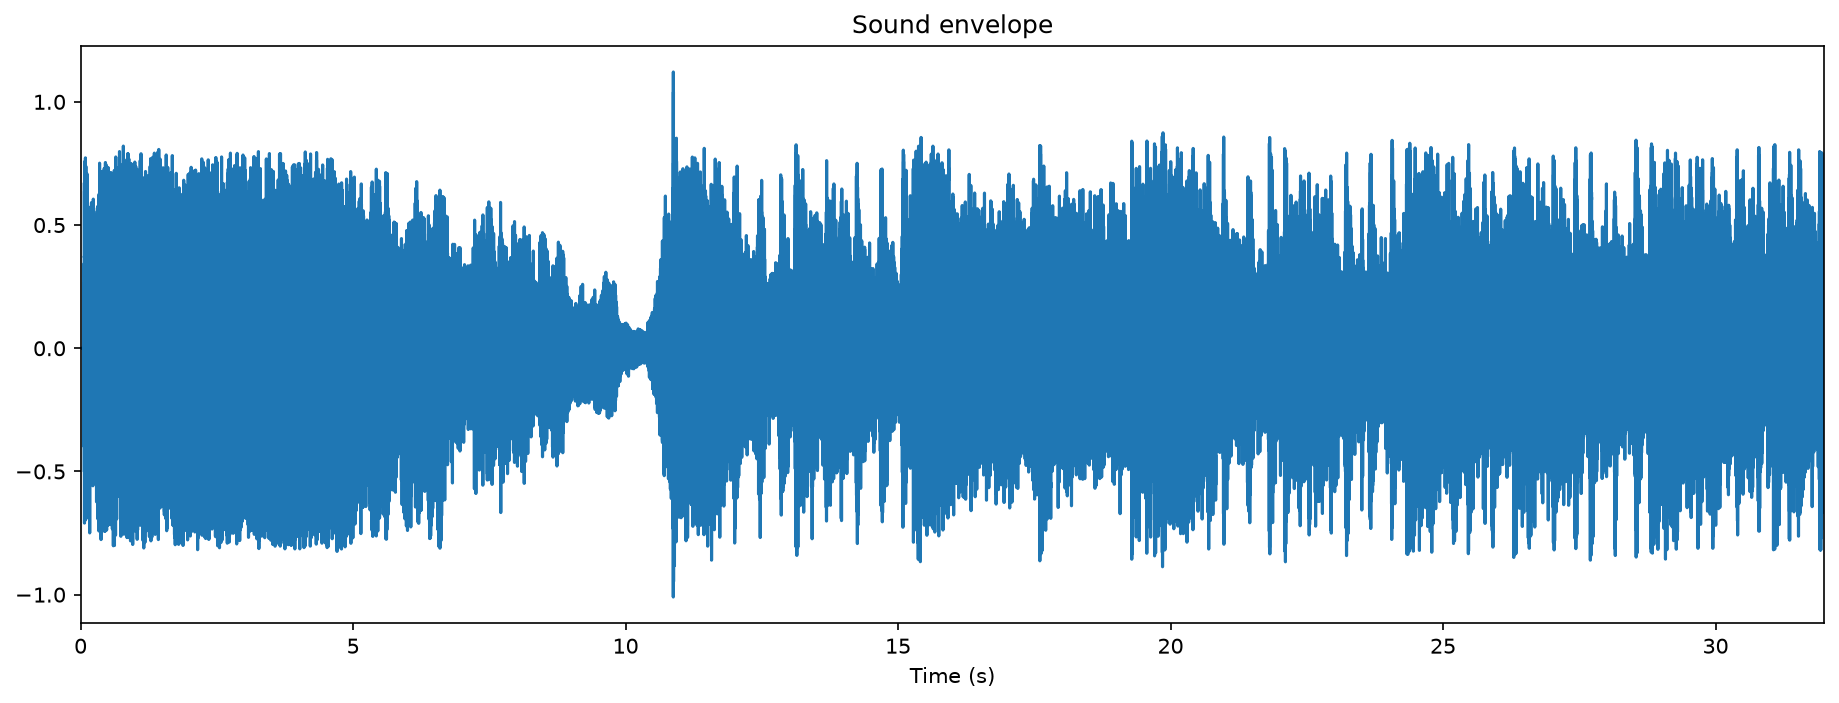

In [ ]:
duration = 32  # in seconds
sr = 22050
hop_length = 2048
# True bkpt 10s both harmonic and drop-in
# y, sr = librosa.load("D:/Intrest/radio_listener/streams/radio_Bollywood 2010's/2026-09-15_21-18-24.mp3", sr=sr)
# True bkpt 2, sweeper between 14-15s
# y, sr = librosa.load("D:/Intrest/radio_listener/streams/radio_Bollywood 2010's/2026-09-15_21-22-08.mp3", sr=sr)
# Strong breakpoint at 11s not harmonic
# y, sr = librosa.load("D:/Intrest/radio_listener/streams/radio_Mirchi Love/2026-09-15_21-17-40.mp3", sr=sr)
# breakpoint at 11s end
# y, sr = librosa.load("D:/Intrest/radio_listener/streams/radio_Mirchi Love/2026-09-15_21-22-08.mp3", sr=sr)
# No breaks example
# y, sr = librosa.load("D:/Intrest/radio_listener/streams/radio_Mirchi Love/2026-09-15_21-18-24.mp3", sr=sr)
# test
y, sr = librosa.load("D:/Intrest/radio_listener/streams/radio_radioBollyFM/2026-09-15_21-19-07.mp3", sr=sr)

# listen to the music
display(Audio(data=y, rate=sr))

# look at the envelope
fig, ax = fig_ax()
ax.plot(np.arange(y.size) / sr, y)
ax.set_xlim(0, y.size / sr)
ax.set_xlabel("Time (s)")
_ = ax.set(title="Sound envelope")


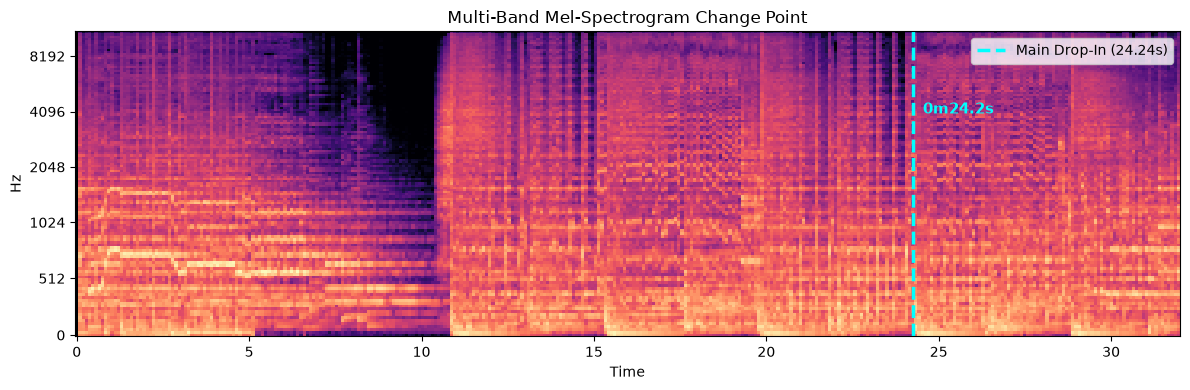

In [397]:
# ==========================================
# 2. Extract Multi-Band Log-Mel Features
# ==========================================
# 16 Mel bands capture bass, mids, and high-frequency energy shifts independently
S = librosa.feature.melspectrogram(
    y=y, sr=sr, n_mels=16, hop_length=hop_length
)
S_dB = librosa.power_to_db(S, ref=np.max)

# Transpose for ruptures: shape becomes (n_frames, 16_mel_bands)
features = zscore(S_dB, axis=1).T

# ==========================================
# 3. Window Search across Frequency Bands
# ==========================================
# 3-second sliding window evaluates spectral density state changes
window_sec = 3.0
width_frames = int((window_sec * sr) / hop_length)

algo_1 = rpt.Window(model="rbf", width=width_frames, jump=2).fit(features)

# Request the single dominant macro change point (n_bkps=1)
predicted_frames = algo_1.predict(pen=50)

if len(predicted_frames) == 0:
    cut_timestamps = []
    print("No breakpoints detected.")
    exit()

# Backtrack to the exact transient attack frame
onset_frames = librosa.onset.onset_detect(
    y=y, sr=sr, hop_length=hop_length, backtrack=True, units="frames"
)

raw_frame = predicted_frames[0]
valid_onsets = onset_frames[onset_frames <= raw_frame + 10]
exact_frame = valid_onsets[-1] if len(valid_onsets) > 0 else raw_frame

exact_time = librosa.frames_to_time(exact_frame, sr=sr, hop_length=hop_length)

# ==========================================
# 4. Plot Result over Spectrogram
# ==========================================
fig, ax = plt.subplots(figsize=(12, 4))
S_full = librosa.power_to_db(
    librosa.feature.melspectrogram(y=y, sr=sr, hop_length=hop_length),
    ref=np.max,
)
img = librosa.display.specshow(
    S_full,
    y_axis="mel",
    x_axis="time",
    sr=sr,
    hop_length=hop_length,
    ax=ax,
    cmap="magma",
)

mins, secs = divmod(exact_time, 60)
ax.axvline(
    x=exact_time,
    color="cyan",
    linestyle="--",
    linewidth=2.5,
    label=f"Main Drop-In ({exact_time:.2f}s)",
)
ax.text(
    exact_time + 0.3,
    4000,
    f"{int(mins)}m{secs:04.1f}s",
    color="cyan",
    fontweight="bold",
    fontsize=11,
)

ax.set_title("Multi-Band Mel-Spectrogram Change Point", fontsize=12)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

display(Audio(y, rate=sr))

Ruptures Detected Sweepers (Raw Breakpoints): [10.21678005]


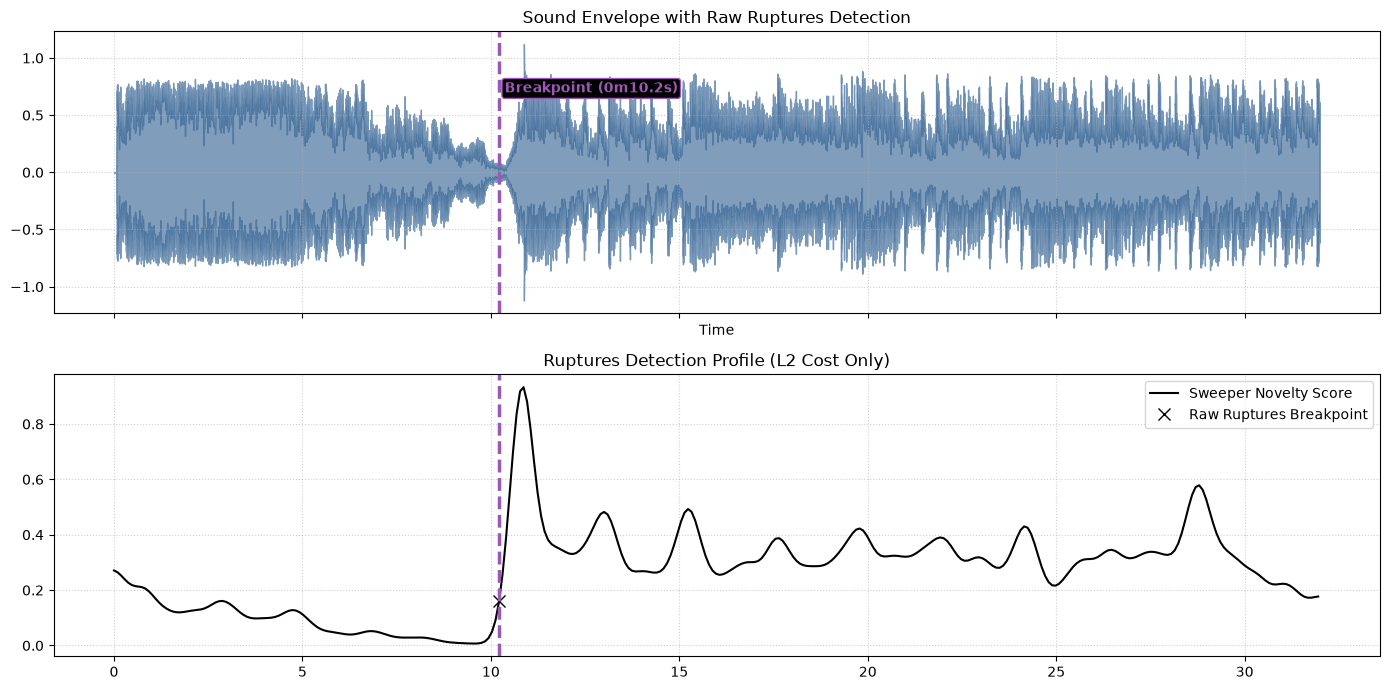

In [398]:
# Extract features
y_harmonic, y_percussive = librosa.effects.hpss(y)
rms_harmonic = librosa.feature.rms(y=y_harmonic, hop_length=hop_length)[0]
rms_percussive = librosa.feature.rms(y=y_percussive, hop_length=hop_length)[0]
spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hop_length)[0]

# Normalize and calculate score
rms_h_norm = rms_harmonic / (np.max(rms_harmonic) + 1e-6)
rms_p_norm = rms_percussive / (np.max(rms_percussive) + 1e-6)
spec_c_norm = spec_centroid / (np.max(spec_centroid) + 1e-6)

sweeper_score = gaussian_filter1d((rms_p_norm * spec_c_norm) / (rms_h_norm + 0.05), sigma=3)

# ==========================================
# 2. Ruptures Window Search (Raw)
# ==========================================
signal = sweeper_score.reshape(-1, 1)
width_frames = int((3.0 * sr) / hop_length)

# Run Window search with L2 cost
algo_2 = rpt.Window(model="l1", width=width_frames, jump=2).fit(signal)
raw_breakpoints = algo_2.predict(pen=15)[:-1]

detected_sweepers = librosa.frames_to_time(raw_breakpoints, sr=sr, hop_length=hop_length)
print(f"Ruptures Detected Sweepers (Raw Breakpoints): {detected_sweepers}")

# ==========================================
# 3. Visualization & Preview
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top Plot: Sound Envelope
librosa.display.waveshow(y, sr=sr, ax=ax1, alpha=0.6, color="#2b5c8f")
ax1.set_title("Sound Envelope with Raw Ruptures Detection", fontsize=12)
ax1.grid(True, linestyle=":", alpha=0.6)

# Bottom Plot: Sweeper Novelty Score
times = librosa.frames_to_time(np.arange(len(sweeper_score)), sr=sr, hop_length=hop_length)
ax2.plot(times, sweeper_score, color="#020101", linewidth=1.5, label="Sweeper Novelty Score")

# Mark raw breakpoints directly on the score curve
if len(raw_breakpoints) > 0:
    ax2.plot(librosa.frames_to_time(raw_breakpoints, sr=sr, hop_length=hop_length), 
             sweeper_score[raw_breakpoints], "x", color="black", markersize=8, label="Raw Ruptures Breakpoint")

ax2.set_title("Ruptures Detection Profile (L2 Cost Only)", fontsize=12)
ax2.legend(loc="upper right")
ax2.grid(True, linestyle=":", alpha=0.6)

# Overlay detection lines on both plots
for t in detected_sweepers:
    mins, secs = divmod(t, 60)
    label = f"Breakpoint ({int(mins)}m{secs:04.1f}s)"
    
    ax1.axvline(x=t, color="#9b59b6", linestyle="--", linewidth=2.5)
    ax1.text(t + 0.15, 0.7, label, color="#9b59b6", fontweight="bold", fontsize=10,
             bbox=dict(boxstyle="round,pad=0.2", fc="black", ec="#9b59b6", lw=1))
    
    ax2.axvline(x=t, color="#9b59b6", linestyle="--", linewidth=2.5)

plt.tight_layout()
plt.show()

display(Audio(y, rate=sr))

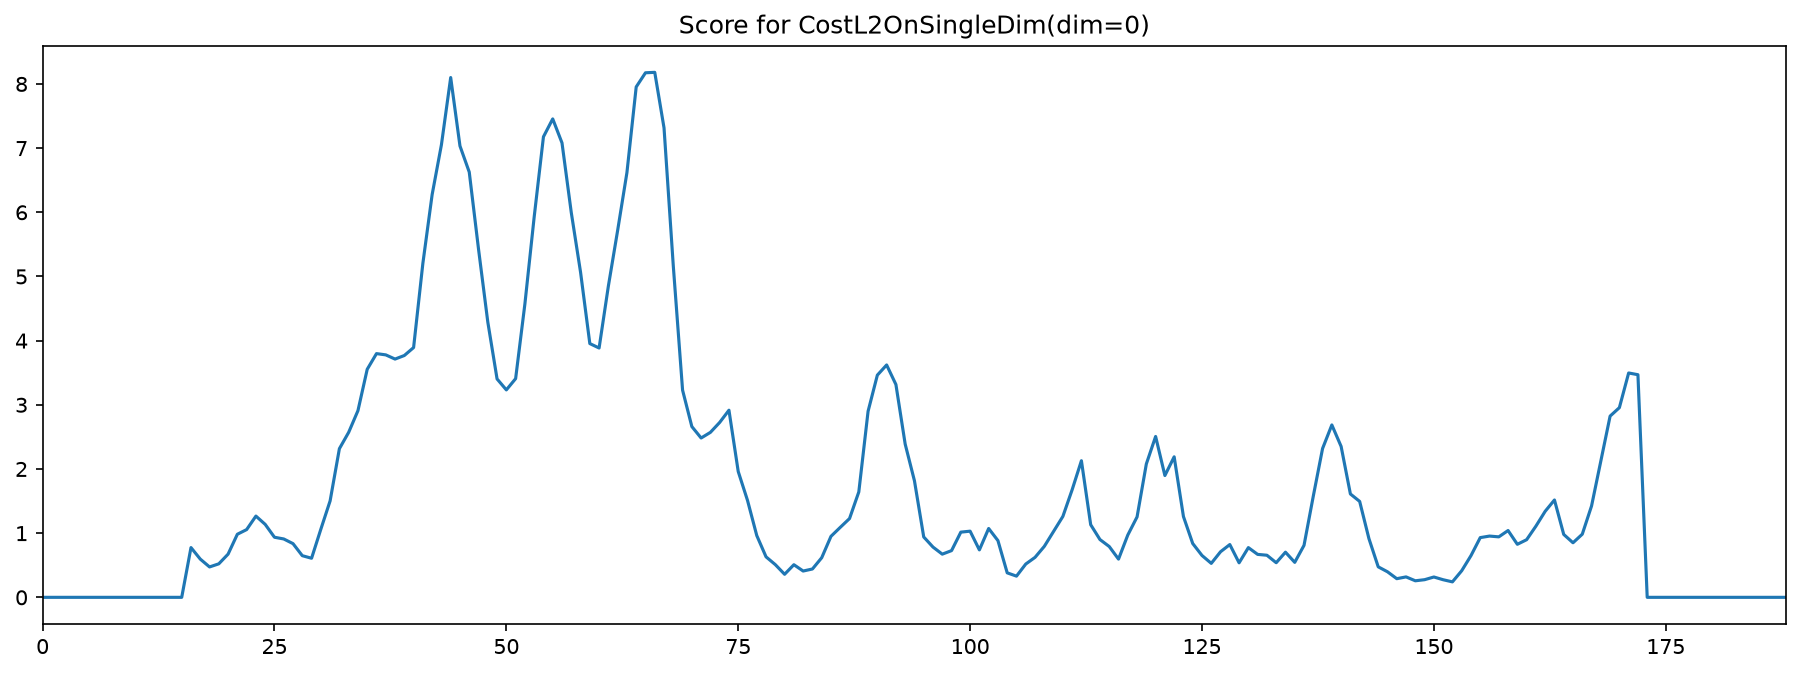

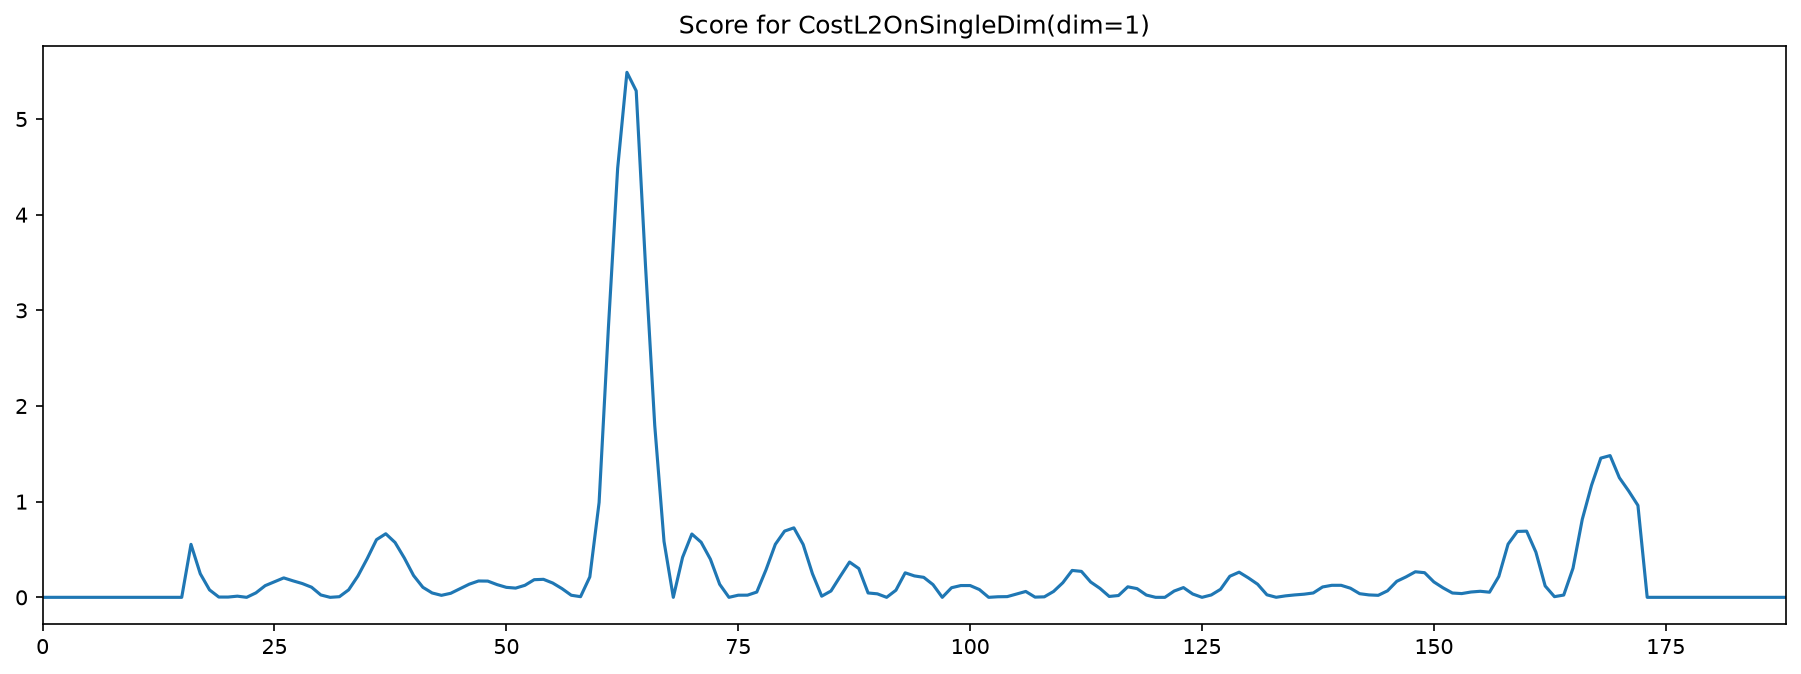

In [399]:
for dim, algo in enumerate([algo_1, algo_2]):
    fig, ax = fig_ax()
    ax.plot(np.r_[np.zeros(width_frames // 2), algo.score, np.zeros(width_frames // 2)])
    ax.set_xmargin(0)
    ax.set_title(f"Score for CostL2OnSingleDim(dim={dim})")


In [400]:
np.where(minmax_scale(algo_1.score) >= minmax_scale(algo_2.score), '1', '2')
algo_2.score[-12:]

array([0.47212993, 0.11887771, 0.00698367, 0.02386485, 0.30426437,
       0.81554664, 1.17173357, 1.45537106, 1.48181442, 1.25043813,
       1.11203243, 0.96085081])

In [401]:
def minmax_scale(array: np.ndarray) -> np.ndarray:
    """Scale each dimension to the [0, 1] range."""
    return (array - np.min(array, axis=0)) / (
        np.max(array, axis=0) - np.min(array, axis=0) + 1e-8
    )


Ruptures Detected breakpoints: [10.21678005]


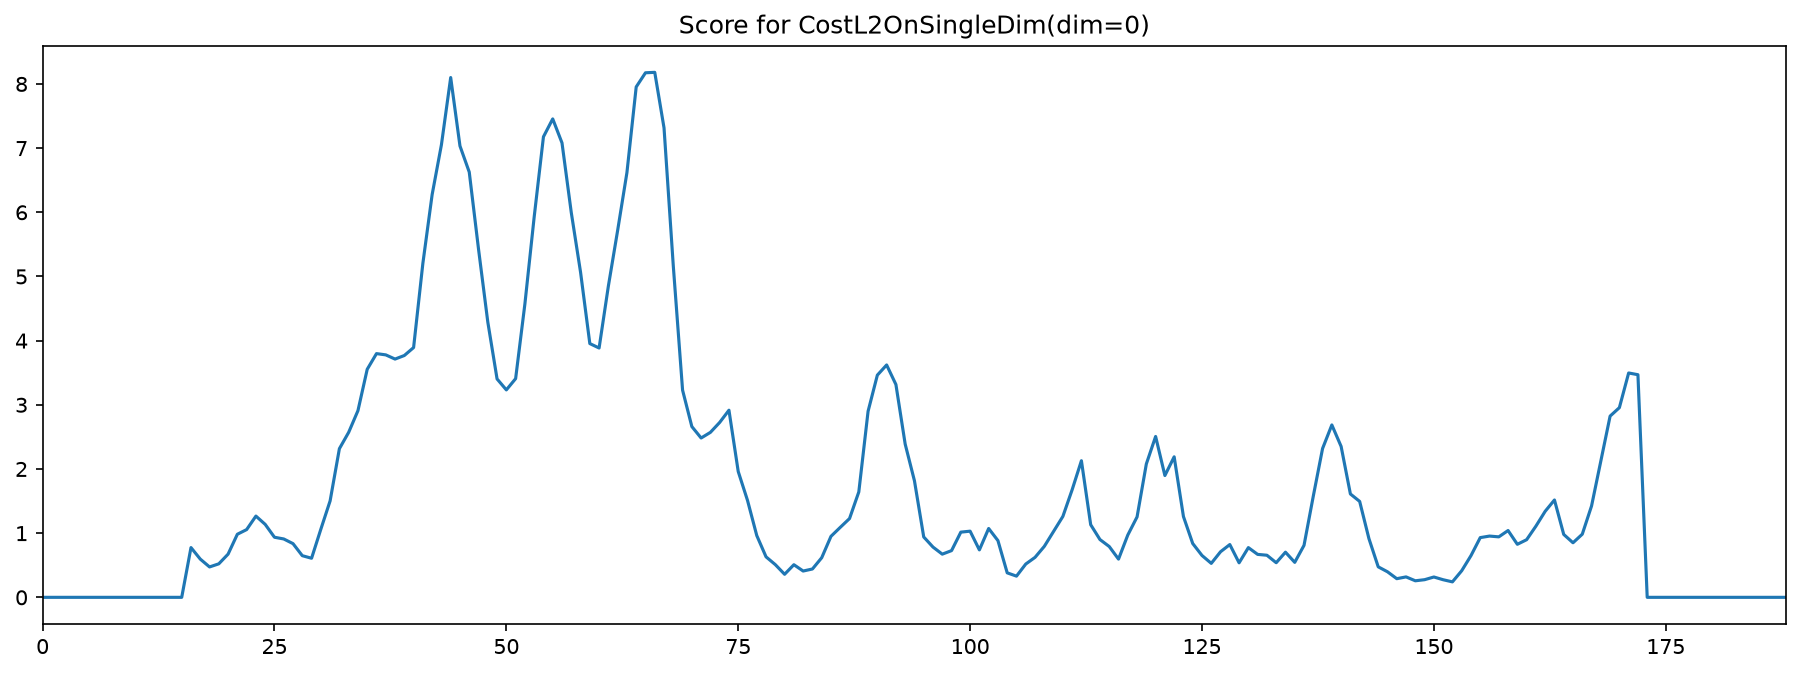

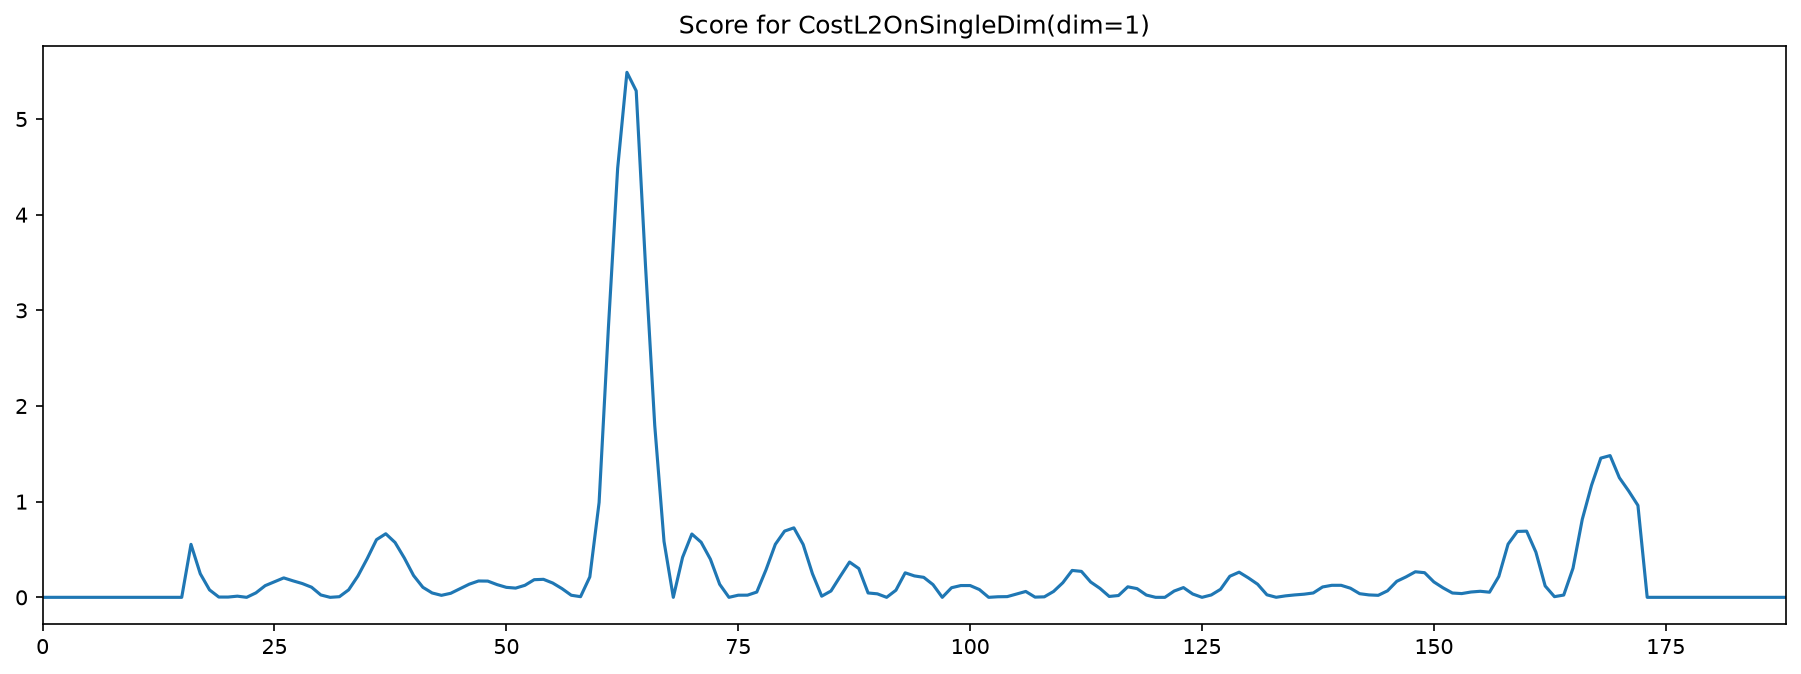

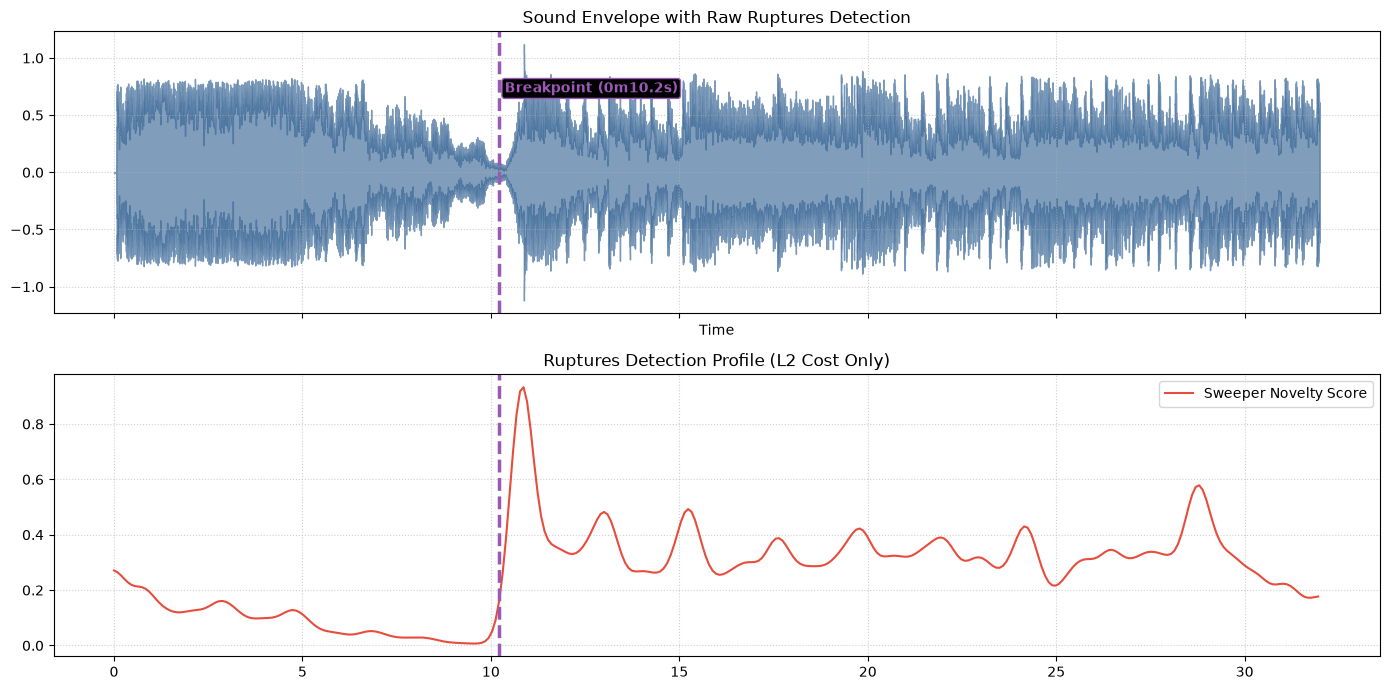

In [402]:
score_arr = np.c_[algo_1.score, algo_2.score]
something = np.vstack([S_dB, sweeper_score])
# intersection aggregation
algo_expert_union  = rpt.Window(width=width_frames, jump=2).fit(something.T)
algo_expert_union.score = (score_arr).min(
    axis=1
)  # scaling + pointwise min
# only one change point is shared by both dimensions
bkps_union_predicted = algo_expert_union.predict(pen=30000)[:-1]
union_bkps = librosa.frames_to_time(bkps_union_predicted, sr=sr, hop_length=hop_length)
print(f"Ruptures Detected breakpoints: {union_bkps}")

# ==========================================
# 3. Visualization & Preview
# ==========================================
for dim, algo in enumerate([algo_1, algo_2]):
    fig, ax = fig_ax()
    ax.plot(np.r_[np.zeros(width_frames // 2), algo.score, np.zeros(width_frames // 2)])
    ax.set_xmargin(0)
    ax.set_title(f"Score for CostL2OnSingleDim(dim={dim})")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top Plot: Sound Envelope
librosa.display.waveshow(y, sr=sr, ax=ax1, alpha=0.6, color="#2b5c8f")
ax1.set_title("Sound Envelope with Raw Ruptures Detection", fontsize=12)
ax1.grid(True, linestyle=":", alpha=0.6)

# Bottom Plot: Sweeper Novelty Score
times = librosa.frames_to_time(np.arange(len(sweeper_score)), sr=sr, hop_length=hop_length)
ax2.plot(times, sweeper_score, color="#e74c3c", linewidth=1.5, label="Sweeper Novelty Score")

# Mark raw breakpoints directly on the score curve
if len(valid_breakpoints) > 0:
    ax2.plot(librosa.frames_to_time(valid_breakpoints, sr=sr, hop_length=hop_length), 
             sweeper_score[valid_breakpoints], "x", color="black", markersize=8, label="Union breakpoints")

ax2.set_title("Ruptures Detection Profile (L2 Cost Only)", fontsize=12)
ax2.legend(loc="upper right")
ax2.grid(True, linestyle=":", alpha=0.6)

# Overlay detection lines on both plots
for t in union_bkps:
    mins, secs = divmod(t, 60)
    label = f"Breakpoint ({int(mins)}m{secs:04.1f}s)"
    
    ax1.axvline(x=t, color="#9b59b6", linestyle="--", linewidth=2.5)
    ax1.text(t + 0.15, 0.7, label, color="#9b59b6", fontweight="bold", fontsize=10,
             bbox=dict(boxstyle="round,pad=0.2", fc="black", ec="#9b59b6", lw=1))
    
    ax2.axvline(x=t, color="#9b59b6", linestyle="--", linewidth=2.5)

plt.tight_layout()
plt.show()

display(Audio(y, rate=sr))